### Unsloth


In [1]:
import os
import json

# Load configuration
config_path = "../configs/hyperparameters.json"
with open(config_path, "r") as f:
    config = json.load(f)

os.environ["CUDA_VISIBLE_DEVICES"] = config["environment"]["cuda_visible_devices"]


In [2]:
import torch
print(f"Có GPU không? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")
else:
    print("PyTorch không tìm thấy GPU.")

Có GPU không? True
Tên GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [3]:
from unsloth import FastLanguageModel
import torch
from dotenv import load_dotenv

load_dotenv()

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = config["model"]["model_name"],
    max_seq_length = config["model"]["max_seq_length"],
    full_finetuning = config["model"]["full_finetuning"],
    token = os.getenv("HF_TOKEN")
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/teamspace/studios/this_studio/generate-amr-data/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: You selected full finetuning support, but 4bit / 8bit is enabled - disabling LoRA / QLoRA.
==((====))==  Unsloth 2026.6.9: Fast Qwen3 patching. Transformers: 5.13.0. vLLM: 0.24.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 12.0. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using bfloat16 full finetuning which cuts memory usage by 50%.
To enable float32 training, use `float32_mixed_precision = True` during FastLanguageModel.from_pretrained


Loading weights: 100%|██████████| 310/310 [00:00<00:00, 957.37it/s] 


unsloth/Qwen3-1.7B does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [4]:
from unsloth.chat_templates import get_chat_template
tokenizer = get_chat_template(
    tokenizer,
    chat_template = config["dataset"]["chat_template"],
)

In [5]:
import os
from datasets import load_dataset
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# Load the dataset from HF
dataset = load_dataset("myduy/raw-amr-reasoning-meaning", token=os.getenv("HF_TOKEN")).shuffle(seed=42)

# By default, it loads into a DatasetDict under the "train" split
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['amr', 'sentence', 'model_respose', 'meaning'],
        num_rows: 54466
    })
})


We now convert the reasoning dataset into conversational format:

In [6]:
import penman

def remove_wiki(amr_text):
    triples = penman.decode(amr_text).triples
    triples = [x for x in triples if x[1] != ":wiki"]
    return penman.encode(penman.Graph(triples))

def flat_amr(amr_text):
    graph = penman.decode(amr_text)
    return penman.encode(graph, indent=0, compact=True).replace("\n", " ")

# Test the function
sample = dataset["train"][1]["amr"]
print("Original: \n",sample)
amr_removed_wiki = remove_wiki(sample)
print("Removed wiki: \n",amr_removed_wiki)
amr_flated = flat_amr(sample)
print("Flated: \n",amr_flated)

Original: 
 (s / strike-01
   :ARG0 (q / quake
            :quant (s2 / seismic-quantity
                       :quant 7.1))
   :ARG1 (d / desert)
   :time (d2 / date-entity
             :year 1999))
Removed wiki: 
 (s / strike-01
   :ARG0 (q / quake
            :quant (s2 / seismic-quantity
                       :quant 7.1))
   :ARG1 (d / desert)
   :time (d2 / date-entity
             :year 1999))
Flated: 
 (s / strike-01 :ARG0 (q / quake :quant (s2 / seismic-quantity :quant 7.1)) :ARG1 (d / desert) :time (d2 / date-entity :year 1999))


In [7]:
import sys
import os
import re
sys.path.append(os.path.abspath(".."))
from services.amr_hint.prompt_builder import build_prompt

def clean_model_respose(response):
    response = re.sub(r"<amr>.*?</amr>", "", response, flags=re.DOTALL)
    response = response.replace("<think>", "").replace("</think>", "")
    return response.strip()

def generate_conversation(examples):
    inputs  = examples["sentence"]
    outputs = examples["amr"]
    meanings = examples["meaning"]
    model_resposes = examples["model_respose"]

    conversations = []
    for input_text, output, meaning, model_respose_list in zip(inputs, outputs, meanings, model_resposes):
        system_prompt = build_prompt(input_text, output)
        cleaned_output = remove_wiki(output)
        cleaned_output = flat_amr(cleaned_output)
        
        if isinstance(model_respose_list, list) and len(model_respose_list) > 0:
            candidates = model_respose_list
        else:
            candidates = [str(model_respose_list)]

        user_msg = (
            "Convert the following English sentence into its Abstract Meaning"
            f" Representation (AMR):\n\n<sentence>{input_text}</sentence>"
        )
        for raw_reasoning in candidates:
            reasoning = clean_model_respose(raw_reasoning)
            assistant_msg = f"<think>{meaning.strip()} {reasoning.strip()}</think>\n\n<amr>{cleaned_output}</amr>"
            conversations.append([
                # {"role" : "system",     "content" : system_prompt},
                {"role" : "user",      "content" : user_msg},
                {"role" : "assistant", "content" : assistant_msg},
            ])

    return { "conversations": conversations, }

# Deduplicate input sentences
seen_texts = set()
def filter_duplicates(example):
    if example["sentence"] in seen_texts:
        return False
    seen_texts.add(example["sentence"])
    return True

dataset = dataset.filter(filter_duplicates)
dataset = dataset.map(generate_conversation, batched = True, remove_columns=dataset["train"].column_names)

Map: 100%|██████████| 54140/54140 [00:31<00:00, 1716.99 examples/s]


We now have to apply the chat template for `Qwen-3` onto the conversations, and save it to `text`.

In [8]:
def formatting_prompts_func(examples):
   convos = examples["conversations"]
   texts = [tokenizer.apply_chat_template(convo, tokenize = False, add_generation_prompt = False) for convo in convos]
   return { "text" : texts, }

dataset = dataset.map(formatting_prompts_func, batched = True)

Map: 100%|██████████| 162420/162420 [00:09<00:00, 16915.30 examples/s]


Map (num_proc=32): 100%|██████████| 162420/162420 [00:04<00:00, 34116.24 examples/s]


Tổng số mẫu: 162420
Số token trung bình: 655.48
Số token trung vị: 662.00
Số token min: 109
Số token max: 8289
Độ lệch chuẩn: 195.33

Percentiles:
25%: 538
50%: 662
75%: 772
90%: 881
95%: 957
99%: 1139


/tmp/ipykernel_156026/3098750434.py:48: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(token_counts, vert=True)


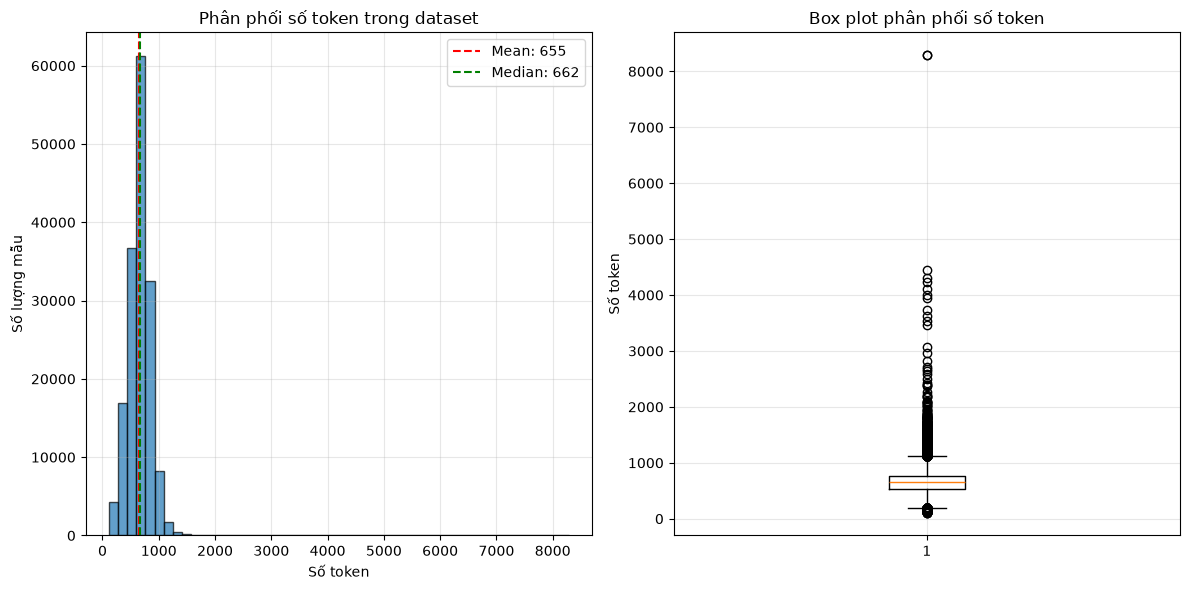

In [9]:
# Phân tích phân phối số token trong dataset
import numpy as np
import matplotlib.pyplot as plt

def count_tokens(examples):
    texts = examples["text"]
    token_counts = []
    for text in texts:
        tokens = tokenizer(text, truncation=False)["input_ids"]
        token_counts.append(len(tokens))
    return {"token_count": token_counts}

# Áp dụng hàm đếm token
dataset_with_counts = dataset["train"].map(count_tokens, batched=True, num_proc =32)

# Lấy danh sách số token
token_counts = dataset_with_counts["token_count"]

# Thống kê cơ bản
print(f"Tổng số mẫu: {len(token_counts)}")
print(f"Số token trung bình: {np.mean(token_counts):.2f}")
print(f"Số token trung vị: {np.median(token_counts):.2f}")
print(f"Số token min: {np.min(token_counts)}")
print(f"Số token max: {np.max(token_counts)}")
print(f"Độ lệch chuẩn: {np.std(token_counts):.2f}")
print(f"\nPercentiles:")
print(f"25%: {np.percentile(token_counts, 25):.0f}")
print(f"50%: {np.percentile(token_counts, 50):.0f}")
print(f"75%: {np.percentile(token_counts, 75):.0f}")
print(f"90%: {np.percentile(token_counts, 90):.0f}")
print(f"95%: {np.percentile(token_counts, 95):.0f}")
print(f"99%: {np.percentile(token_counts, 99):.0f}")

# Vẽ histogram
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(token_counts, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Số token')
plt.ylabel('Số lượng mẫu')
plt.title('Phân phối số token trong dataset')
plt.axvline(np.mean(token_counts), color='r', linestyle='--', label=f'Mean: {np.mean(token_counts):.0f}')
plt.axvline(np.median(token_counts), color='g', linestyle='--', label=f'Median: {np.median(token_counts):.0f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(token_counts, vert=True)
plt.ylabel('Số token')
plt.title('Box plot phân phối số token')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Let's see how the chat template did!


In [10]:
dataset["train"][100]['text']

'<|im_start|>user\nConvert the following English sentence into its Abstract Meaning Representation (AMR):\n\n<sentence>\'John Reid could buy one ship a week at this rate and moor a whole armada of them around the coast without solving the crisis.</sentence><|im_end|>\n<|im_start|>assistant\n<think>\nThe sentence expresses that if the current situation continues, John Reid would have the capacity to purchase one ship every week and station a massive fleet of them along the coastline, yet even this significant accumulation of vessels would fail to resolve the existing crisis. To parse this sentence into AMR, we must identify the core predicates and their arguments:\n\n1.  **Root Predicate**: The sentence expresses a possibility ("could"), so the root is `possible-01`.\n2.  **First Event**: `buy-01`\n    *   **ARG0 (Buyer)**: `person` (John Reid)\n    *   **ARG1 (Thing bought)**: `ship`\n    *   **ARG3 (Price/Rate)**: A frequency/rate of `one` `ship` per `week`.\n3.  **Second Event**: `mo

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

In [11]:
config['model']['model_name'].split("/")[-1].lower()

'qwen3-1.7b'

In [12]:
import os
import wandb
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d-%H%M")
tempt= config['model']['model_name'].split("/")[-1].lower()
run_name = f"{tempt}-amr-{timestamp}"
api_key = os.getenv("WANDB_API_KEY")
wandb.login(key=api_key)

run = wandb.init(
    project=f"sft-llm-amr-parsing", 
    name=run_name
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /teamspace/studios/this_studio/.netrc
wandb: Currently logged in as: 52100882 (mai-duy-edu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


In [13]:
from trl import SFTTrainer, SFTConfig

training_config = config["training"]

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset["train"],
    eval_dataset = None,
    args = SFTConfig(
        dataset_text_field = training_config["dataset_text_field"],
        packing = training_config["packing"],
        per_device_train_batch_size = training_config["per_device_train_batch_size"],
        gradient_accumulation_steps = training_config["gradient_accumulation_steps"],
        warmup_ratio = training_config["warmup_ratio"],
        num_train_epochs = training_config["num_train_epochs"],
        learning_rate = training_config["learning_rate"],
        logging_steps = training_config["logging_steps"],
        optim = training_config["optim"],
        weight_decay = training_config["weight_decay"],
        lr_scheduler_type = training_config["lr_scheduler_type"],
        report_to = training_config["report_to"],
    ),
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Unsloth: Packing train dataset (num_proc=52): 100%|██████████| 162420/162420 [00:00<00:00, 416335.44 examples/s]


🦥 Unsloth: Packing enabled - training is >2x faster and uses less VRAM!


We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs. This helps increase accuracy of finetunes!

In [14]:
from unsloth.chat_templates import train_on_responses_only

response_config = config["train_on_responses"]

trainer = train_on_responses_only(
    trainer,
    instruction_part = response_config["instruction_part"],
    response_part = response_config["response_part"],
)

Filter (num_proc=52): 100%|██████████| 13138/13138 [00:01<00:00, 7455.08 examples/s] 


Let's verify masking the instruction part is done! Let's print the 100th row again.

In [15]:
tokenizer.decode(trainer.train_dataset[100]["input_ids"])

'<|im_start|>user\nConvert the following English sentence into its Abstract Meaning Representation (AMR):\n\n<sentence>Prior to the dutch ships arriving, they sent the sweeper arms to be used on US ships.</sentence><|im_end|>\n<|im_start|>assistant\n<think>\nBefore the Dutch ships reached their destination, they dispatched sweeper arms intended for use on American ships. To parse this sentence into AMR, we need to identify the main event and the temporal relationship.\n\n**Analysis:**\n1.  **Main Event:** `send-03`. The agent is "they" (referring back to the Dutch ships, or more accurately, the entity associated with them), the theme (ARG1) is "sweeper arms", and the purpose/destination involves "US ships".\n2.  **Temporal Clause:** "Prior to the dutch ships arriving". This indicates a temporal relation (`:time`) or a preceding event. The event is `arrive-01` where the ARG1 is "dutch ships".\n3.  **Purpose/Usage:** The "sweeper arms" are intended "to be used on US ships". This can be m

Now let's print the masked out example - you should see only the answer is present:

In [16]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA RTX PRO 6000 Blackwell Server Edition. Max memory = 94.971 GB.
3.236 GB of memory reserved.


Let's train the model! To resume a training run, set `trainer.train(resume_from_checkpoint = True)`

In [ ]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 13,138 | Num Epochs = 1 | Total steps = 411
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 1,720,574,976 of 1,720,574,976 (100.00% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Casting fp32 inputs back to torch.bfloat16 for flash-attn compatibility.


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss


In [ ]:

# Push full model lên HF Hub
model_id = f"viamr-project/{run_name}"
model.push_to_hub(model_id, token = os.getenv("HF_TOKEN"))
tokenizer.push_to_hub(model_id, token = os.getenv("HF_TOKEN"))

print(f"✓ Full model đã được push lên: {run_name}")
print("Model này có thể dùng trực tiếp với vLLM!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.51s/it]
Processing Files (1 / 1): 100%|██████████| 3.44GB / 3.44GB,  304MB/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.
Unsloth: Restored added_tokens_decoder metadata in /tmp/tmptlt5zwwt/tokenizer_config.json.


Saved model to https://huggingface.co/viamr-project/qwen3-1.7b-amr-20260512-1445


Processing Files (1 / 1): 100%|██████████| 11.4MB / 11.4MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


✓ Full model đã được push lên: qwen3-1.7b-amr-20260512-1445
Model này có thể dùng trực tiếp với vLLM!
